# PJM East Electricity Demand Analysis (2002–2018)

## Overview
This project analyzes 145,366 hours of electricity demand data from the PJM East 
grid operator, covering 2002–2018. The goal is to identify demand patterns by time 
of day, day of week, and season, and to flag statistical anomalies that may indicate 
unusual grid conditions.

**Dataset:** PJM Hourly Energy Consumption (Kaggle)  
**Tools:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams["figure.figsize"] = (14, 5)


In [2]:
df = pd.read_csv("PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


if data is not in the right format:

df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce"), output NaT

df["Datetime"].isna().sum(), output bad rows

df = df.dropna(subset=["Datetime"]), drop the bad rows

In [3]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.set_index("Datetime").sort_index()
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


In [4]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


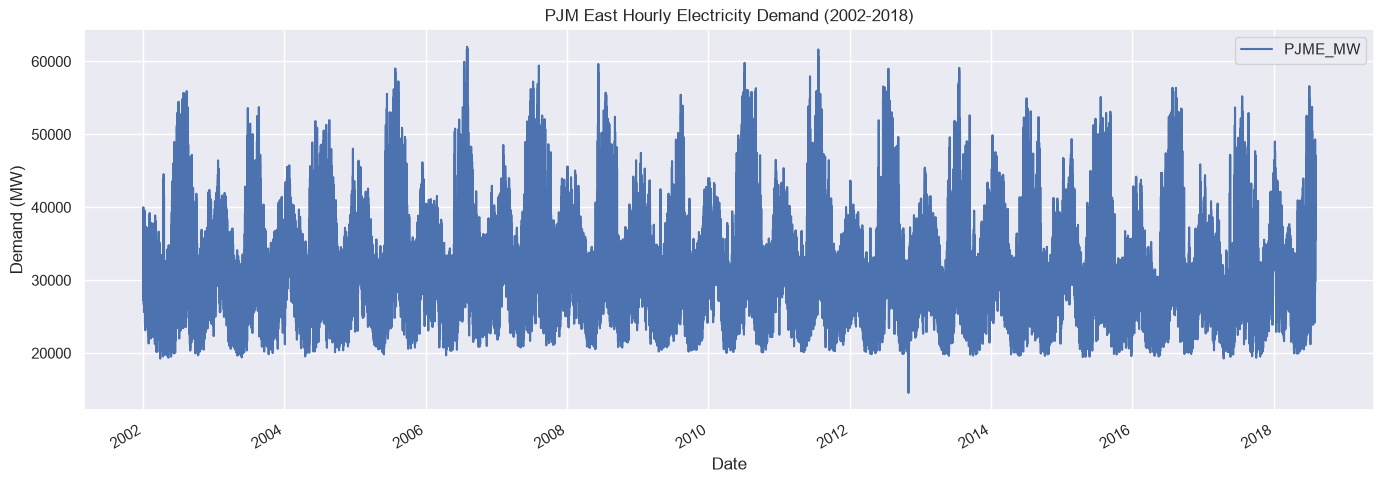

In [5]:
df.plot()
plt.title("PJM East Hourly Electricity Demand (2002-2018)")
plt.ylabel("Demand (MW)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

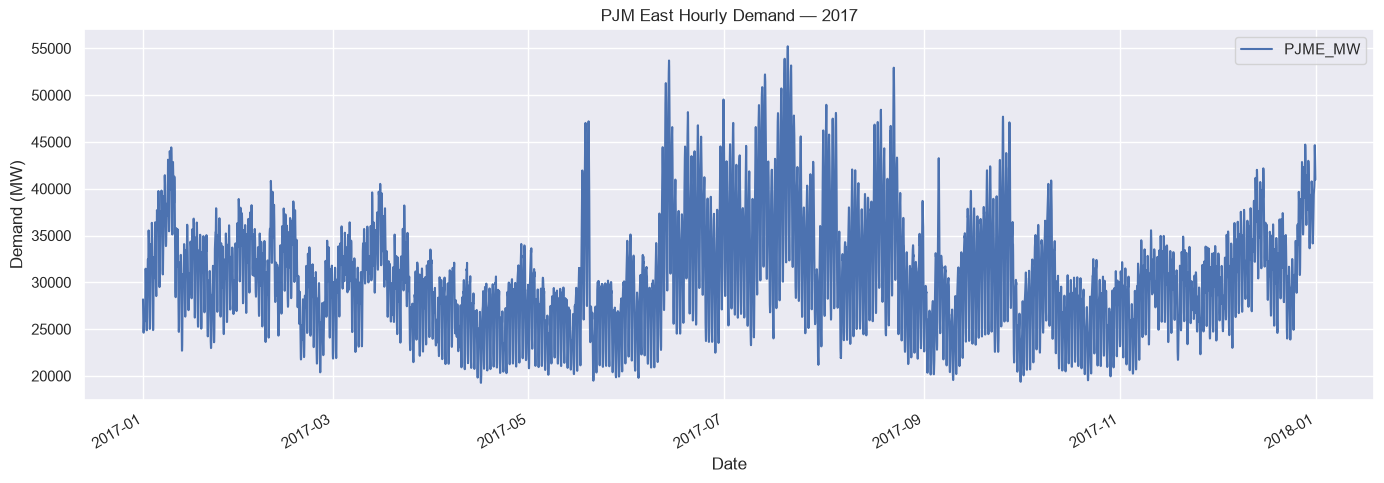

In [6]:
df.loc["2017"].plot()
plt.title("PJM East Hourly Demand — 2017")
plt.ylabel("Demand (MW)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [7]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["year"] = df.index.year
df["season"] = df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
})
df.head()

,PJME_MW,hour,day_of_week,month,year,season
Datetime,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,2002,Winter
2002-01-01 02:00:00,29265.0,2,1,1,2002,Winter
2002-01-01 03:00:00,28357.0,3,1,1,2002,Winter
2002-01-01 04:00:00,27899.0,4,1,1,2002,Winter
2002-01-01 05:00:00,28057.0,5,1,1,2002,Winter


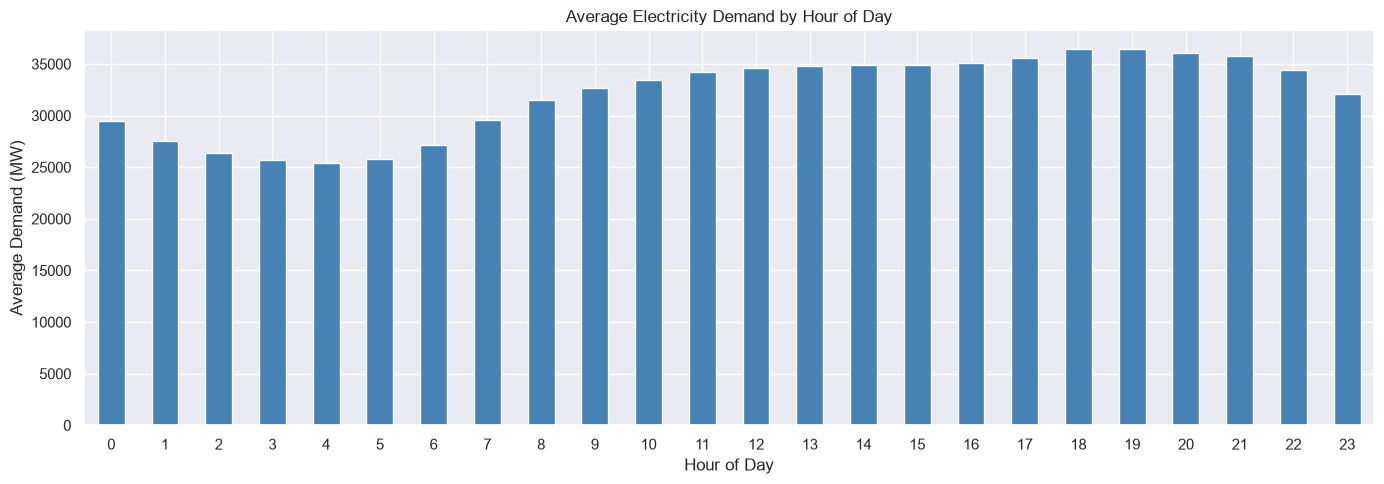

In [8]:
hourly_avg = df.groupby("hour")["PJME_MW"].mean()

hourly_avg.plot(kind="bar", color="steelblue")
plt.title("Average Electricity Demand by Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xlabel("Hour of Day")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

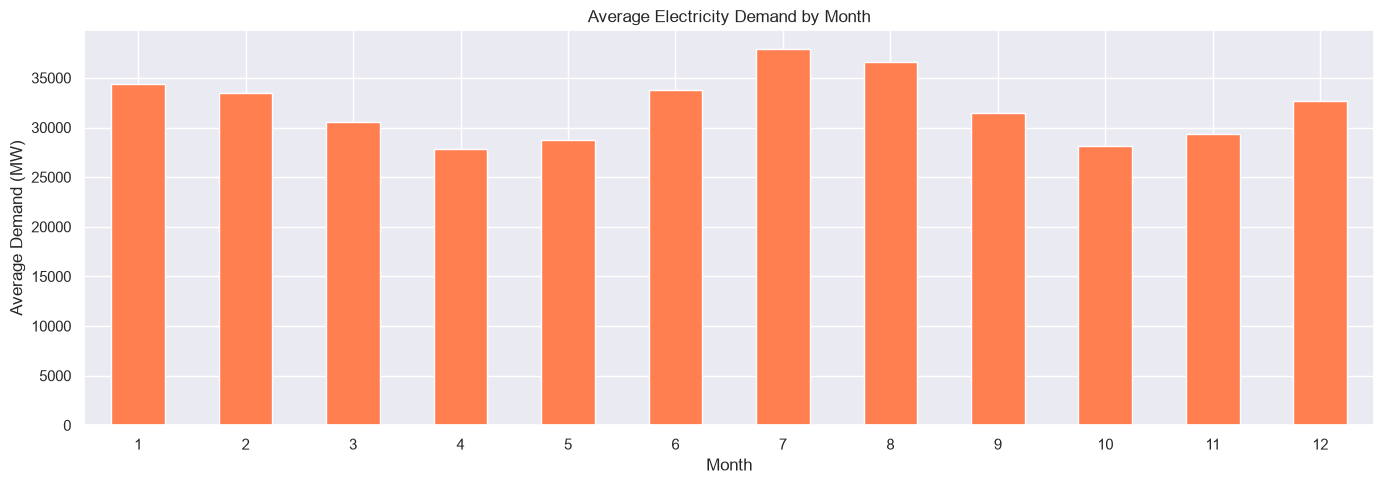

In [9]:
monthly_avg = df.groupby("month")["PJME_MW"].mean()

monthly_avg.plot(kind="bar", color="coral")
plt.title("Average Electricity Demand by Month")
plt.ylabel("Average Demand (MW)")
plt.xlabel("Month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

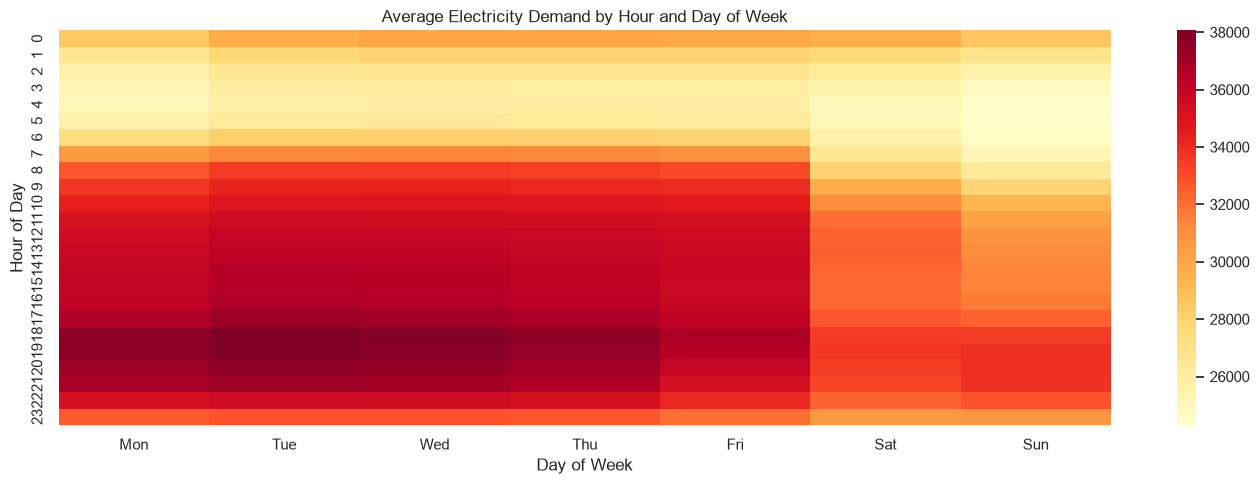

In [16]:
heatmap_data = df.groupby(["hour", "day_of_week"])["PJME_MW"].mean().unstack()

heatmap_data.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

sns.heatmap(heatmap_data, cmap="YlOrRd", fmt=".0f", annot=False)
plt.title("Average Electricity Demand by Hour and Day of Week")
plt.ylabel("Hour of Day")
plt.xlabel("Day of Week")
plt.tight_layout()
plt.show()

C:\Users\edtur\AppData\Local\Temp\ipykernel_12648\3441033237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="season", y="PJME_MW", order=season_order, palette="coolwarm")


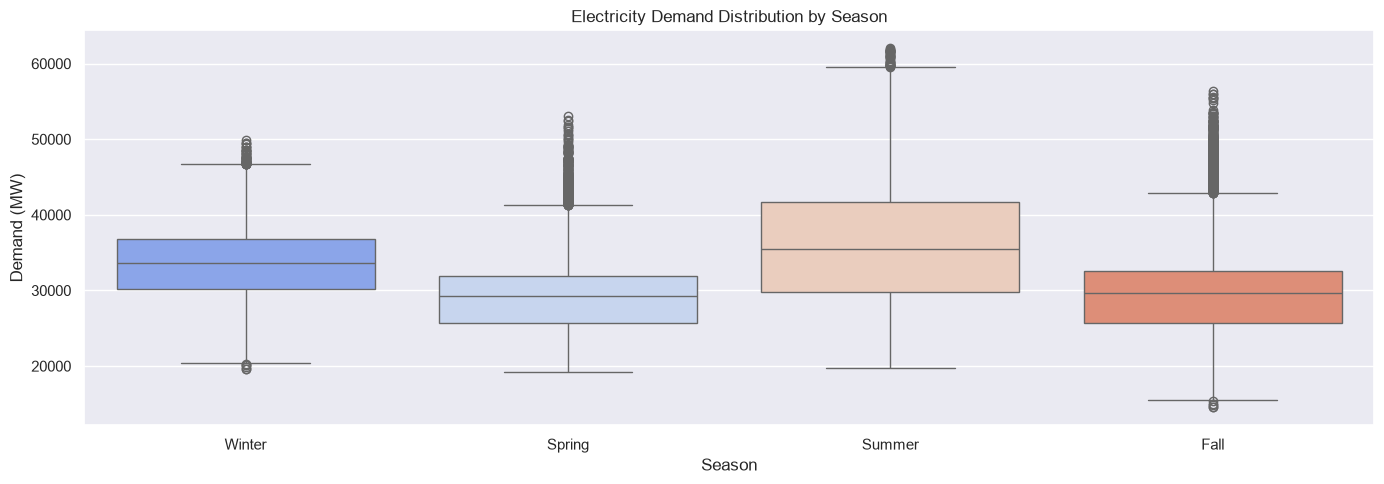

In [11]:
season_order = ["Winter", "Spring", "Summer", "Fall"]

sns.boxplot(data=df, x="season", y="PJME_MW", order=season_order, palette="coolwarm")
plt.title("Electricity Demand Distribution by Season")
plt.ylabel("Demand (MW)")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

In [12]:
df["rolling_mean"] = df["PJME_MW"].rolling(window=24).mean()
df["rolling_std"] = df["PJME_MW"].rolling(window=24).std()

In [13]:
df["z_score"] = (df["PJME_MW"] - df["rolling_mean"]) / df["rolling_std"]

df["anomaly"] = df["z_score"].abs() > 3

print(f"Total anomalies flagged: {df['anomaly'].sum()}")

Total anomalies flagged: 4


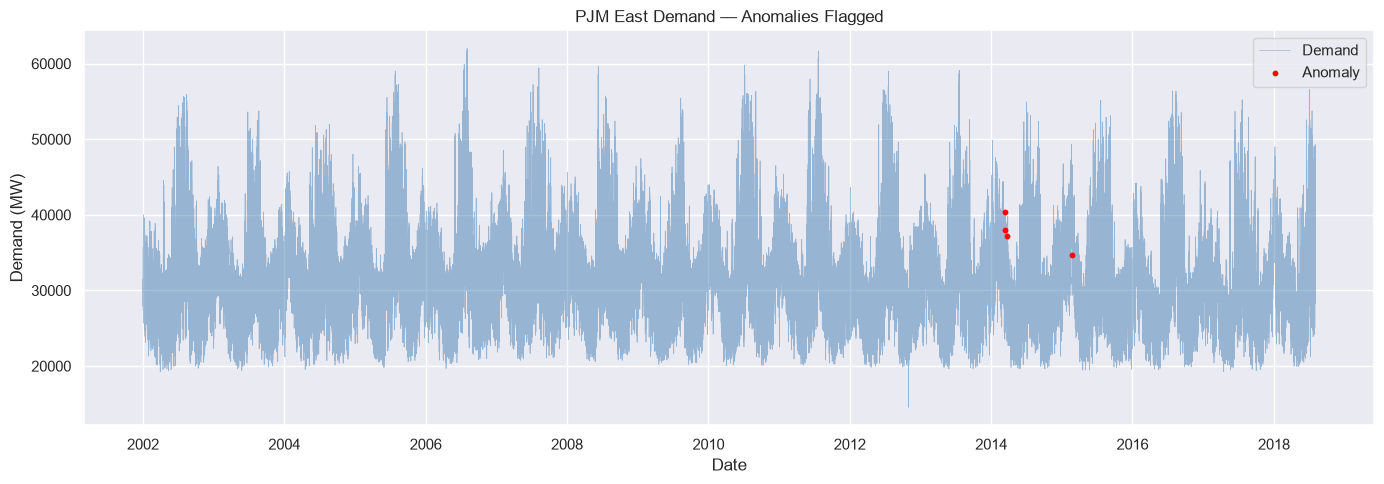

In [14]:
anomalies = df[df["anomaly"] == True]

plt.plot(df.index, df["PJME_MW"], color="steelblue", alpha=0.5, linewidth=0.5, label="Demand")
plt.scatter(anomalies.index, anomalies["PJME_MW"], color="red", s=10, label="Anomaly", zorder=5)
plt.title("PJM East Demand — Anomalies Flagged")
plt.ylabel("Demand (MW)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

## Anomaly Analysis

Four anomalies were flagged using a 24-hour rolling z-score threshold of ±3. 
Three cluster around January–February 2014, consistent with the North American 
Polar Vortex event, which caused extreme demand spikes across the PJM grid. 
One additional anomaly appears in early 2015, likely driven by similar winter 
weather conditions.

## Key Findings

1. **Peak demand occurs around 7pm on weekday evenings**, driven by overlap between 
   commercial activity and residential usage after work hours.

2. **July is the highest demand month**, reflecting heavy air conditioning load 
   across the PJM East region during summer heat.

3. **Summer demand is the most volatile season**, with the widest spread in the 
   boxplot distribution, making it the hardest period to forecast accurately.

4. **Four anomalies were detected** using a 24-hour rolling z-score threshold of ±3. 
   Three cluster around January–February 2014, consistent with the North American 
   Polar Vortex event. One additional anomaly appears in early 2015, likely driven 
   by similar extreme winter conditions.

## Techniques Used
- Datetime feature extraction (hour, day of week, month, season)
- GroupBy aggregation for time pattern analysis
- Seaborn heatmap for hour × day of week demand visualization
- Rolling mean and standard deviation for anomaly detection
- Z-score thresholding to flag statistically unusual readings